Environment: velocity

# Setup

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import seaborn
import decoupler
import single_cell_analysis

In [3]:
# Read saved objects from Cellrank analysis

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_6"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)

adata_genes = adata.raw.var_names.to_numpy()

In [4]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

# Define driver genes

Criteria for dead end driver genes:
- Transcription factor
- Target of Hic2
- High correlation with fate probability
- Differential expression in control and Hic2
- Higher estimated activity in the dead end trajectory

## Check which driver targets are transcription factors

Source for list of transcription factors: https://guolab.wchscu.cn/AnimalTFDB#!/download

In [5]:
tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()
hic2_tfs = numpy.intersect1d(hic2_targets, tf_array)
klf4_tfs = numpy.intersect1d(klf4_targets, tf_array)
shared_tfs = numpy.intersect1d(shared_targets, tf_array)

In [9]:
stem_cell_drivers

Index(['Jarid2', 'Zfp42', 'Mta3', 'Tcf7l1', 'Zfp57', 'Mycn', 'Klf2', 'Six4',
       'Etv1', 'Tfcp2l1', 'Sall1', 'Etv5', 'Rbpj', 'Rest', 'Tfap2c', 'Arid3b',
       'Tsc22d1', 'Pbx2', 'Klf15', 'Sox15'],
      dtype='object', name='gene_names')

In [6]:
# Top 10 dead end drivers among Hic2 target TFs

dead_end_drivers = driver_df.loc[numpy.intersect1d(adata_genes, hic2_tfs)].sort_values("Dead end_corr", ascending=False).head(20).index
driver_df.loc[dead_end_drivers]

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Lrrfip1,0.482279,0.000000e+00,0.000000e+00,0.466742,0.497517,-0.482279,0.000000e+00,0.000000e+00,-0.497517,-0.466743
Tlx2,0.459257,0.000000e+00,0.000000e+00,0.443290,0.474933,-0.459263,0.000000e+00,0.000000e+00,-0.474939,-0.443295
Ovol1,0.415746,0.000000e+00,0.000000e+00,0.399022,0.432192,-0.415743,0.000000e+00,0.000000e+00,-0.432190,-0.399020
Dmrtc2,0.395051,0.000000e+00,0.000000e+00,0.377995,0.411838,-0.395047,0.000000e+00,0.000000e+00,-0.411834,-0.377991
Nfe2l3,0.393331,0.000000e+00,0.000000e+00,0.376249,0.410146,-0.393324,0.000000e+00,0.000000e+00,-0.410139,-0.376242
Zbtb7c,0.347529,3.447745e-275,3.068786e-273,0.329777,0.365034,-0.347527,3.468687e-275,3.087426e-273,-0.365033,-0.329776
Foxp1,0.326674,6.645935e-241,4.572797e-239,0.308646,0.344467,-0.326656,7.080302e-241,4.871667e-239,-0.344450,-0.308628
Cebpb,0.316832,1.080232e-225,6.474273e-224,0.298680,0.334755,-0.316821,1.122795e-225,6.729372e-224,-0.334744,-0.298669
Myc,0.315034,5.588297e-223,3.256000e-221,0.296860,0.332980,-0.315063,5.055232e-223,2.945412e-221,-0.333008,-0.296889


In [8]:
# Top 10 stem cell drivers among Hic2 target TFs

stem_cell_drivers = driver_df.loc[numpy.intersect1d(adata_genes, hic2_tfs)].sort_values("Dead end_corr", ascending=True).head(20).index
driver_df.loc[stem_cell_drivers]

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.428702,0.000000e+00,0.000000e+00,-0.444927,-0.412196,0.428709,0.000000e+00,0.000000e+00,0.412203,0.444934
Zfp42,-0.394330,0.000000e+00,0.000000e+00,-0.411129,-0.377263,0.394330,0.000000e+00,0.000000e+00,0.377264,0.411129
Mta3,-0.392145,0.000000e+00,0.000000e+00,-0.408979,-0.375044,0.392148,0.000000e+00,0.000000e+00,0.375048,0.408982
Tcf7l1,-0.384958,0.000000e+00,0.000000e+00,-0.401905,-0.367747,0.384970,0.000000e+00,0.000000e+00,0.367760,0.401917
Zfp57,-0.360304,1.268809e-297,1.300965e-295,-0.377625,-0.342730,0.360307,1.251393e-297,1.283107e-295,0.342734,0.377628
Mycn,-0.345809,2.973616e-272,2.602474e-270,-0.363339,-0.328034,0.345811,2.951716e-272,2.583307e-270,0.328036,0.363341
Klf2,-0.341174,1.934210e-264,1.624814e-262,-0.358769,-0.323336,0.341170,1.962657e-264,1.648710e-262,0.323333,0.358765
Six4,-0.332394,5.008971e-250,3.728564e-248,-0.350110,-0.314440,0.332393,5.035319e-250,3.748177e-248,0.314439,0.350109
Etv1,-0.314925,8.150404e-223,4.735611e-221,-0.332872,-0.296749,0.314925,8.138481e-223,4.728684e-221,0.296750,0.332873


# Visualize trends of drivers

In [31]:
# Define colors for all three groups

group_colors = [
    "#cbc9ca",
    "#0a652c",
    "#da2e24",
    "#3180bd",
]

adata.uns["group_colors"] = group_colors

control_indices = adata.obs["group"] == "control"
hic2_indices = adata.obs["group"] == "Hic2"
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

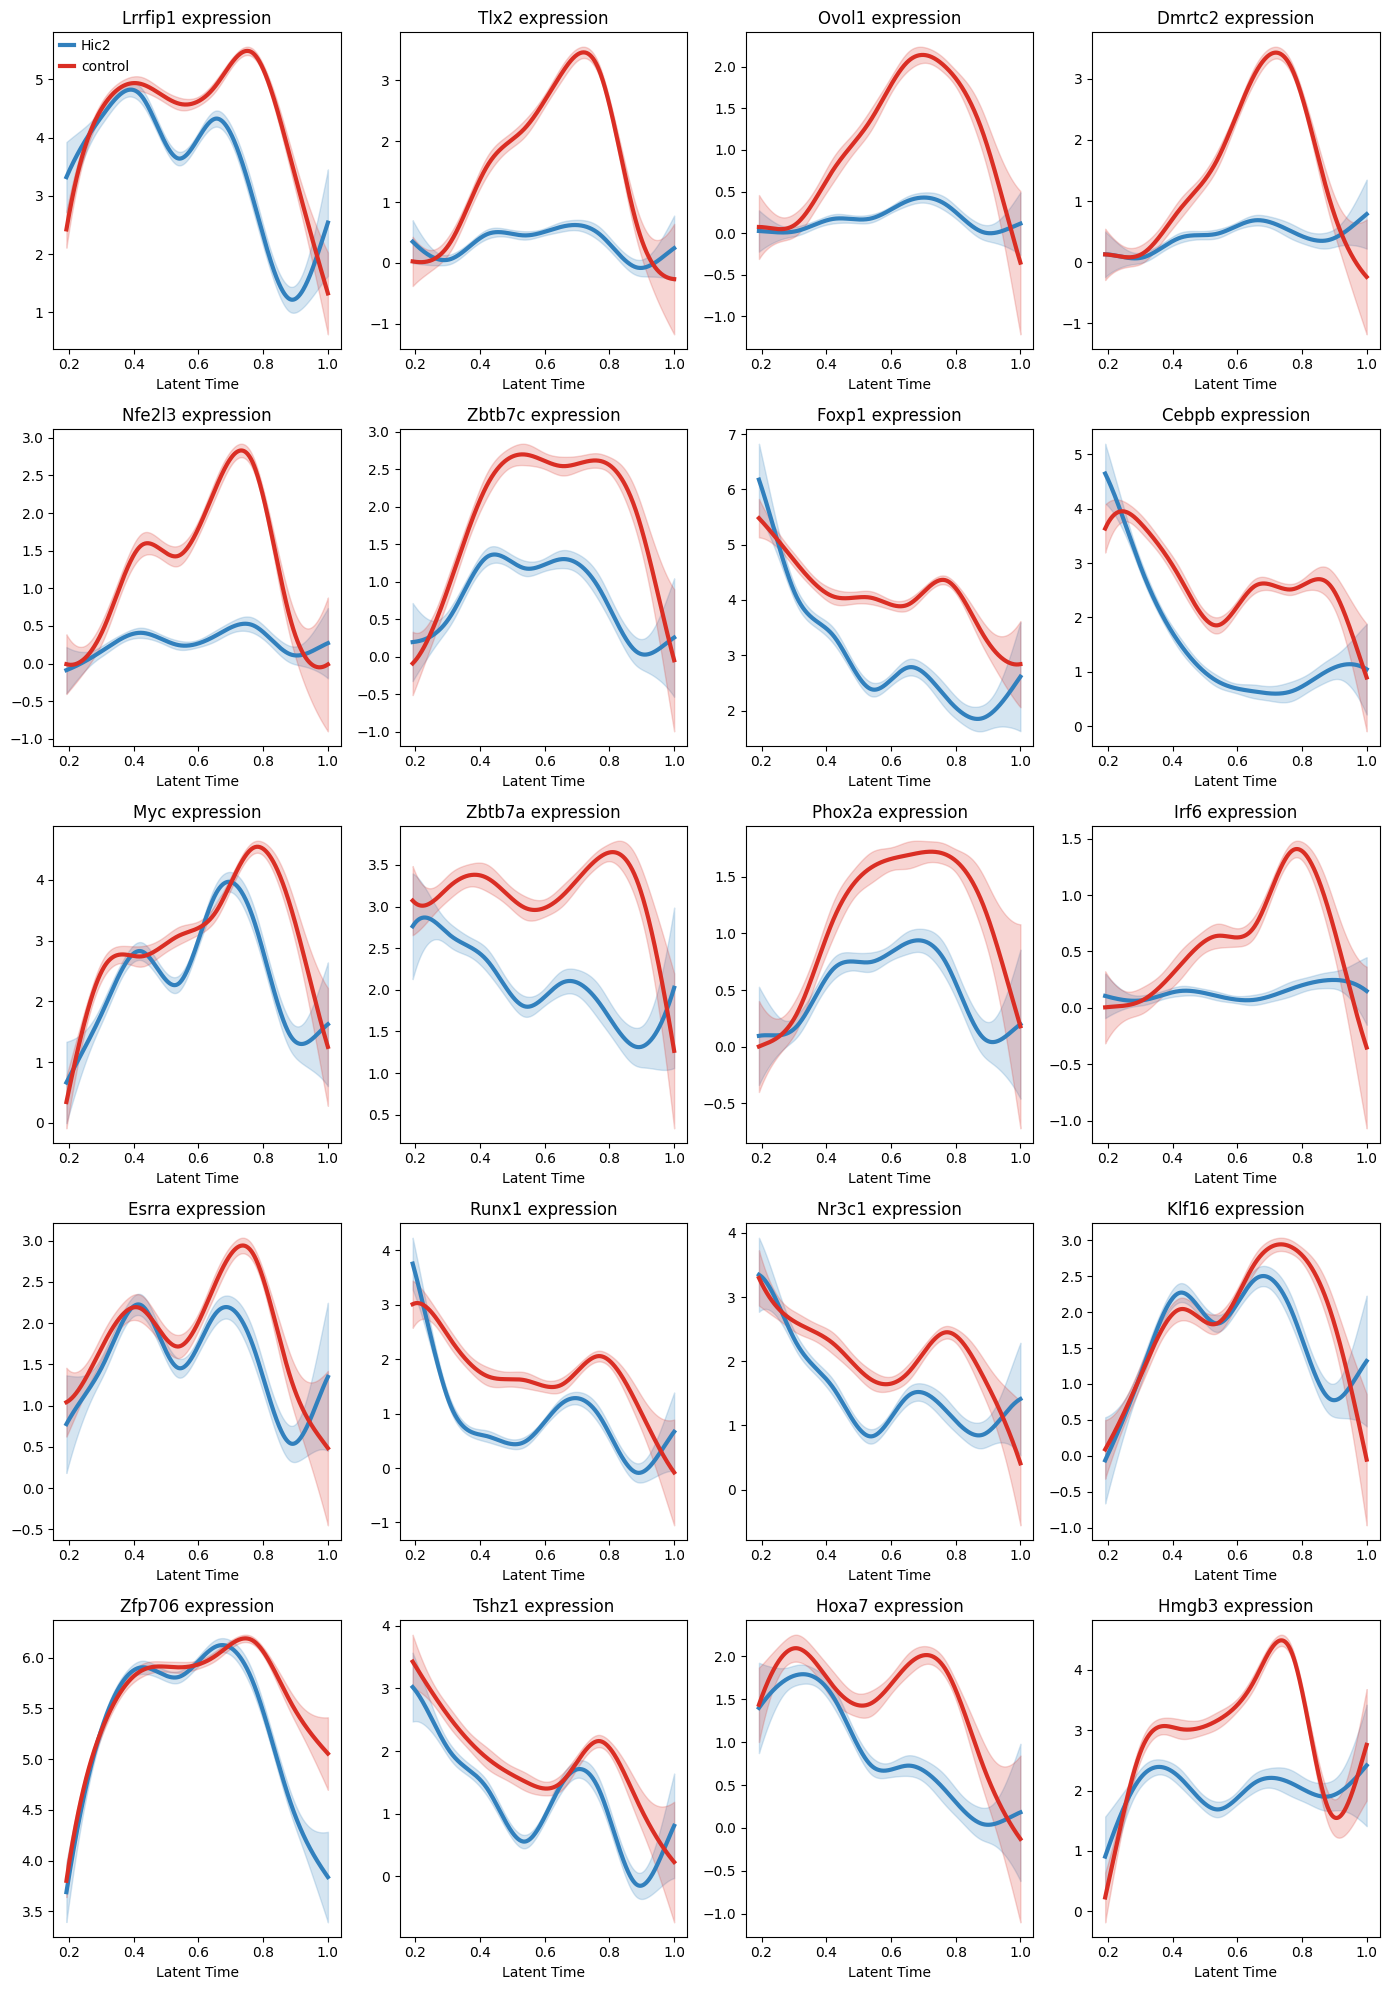

In [33]:
# Expression of dead end drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata, 
    dead_end_drivers, 
    group_key="group",
    groups=["Hic2", "control"],
    layer="raw"
)

  0%|          | 0/20 [00:00<?, ?gene/s]

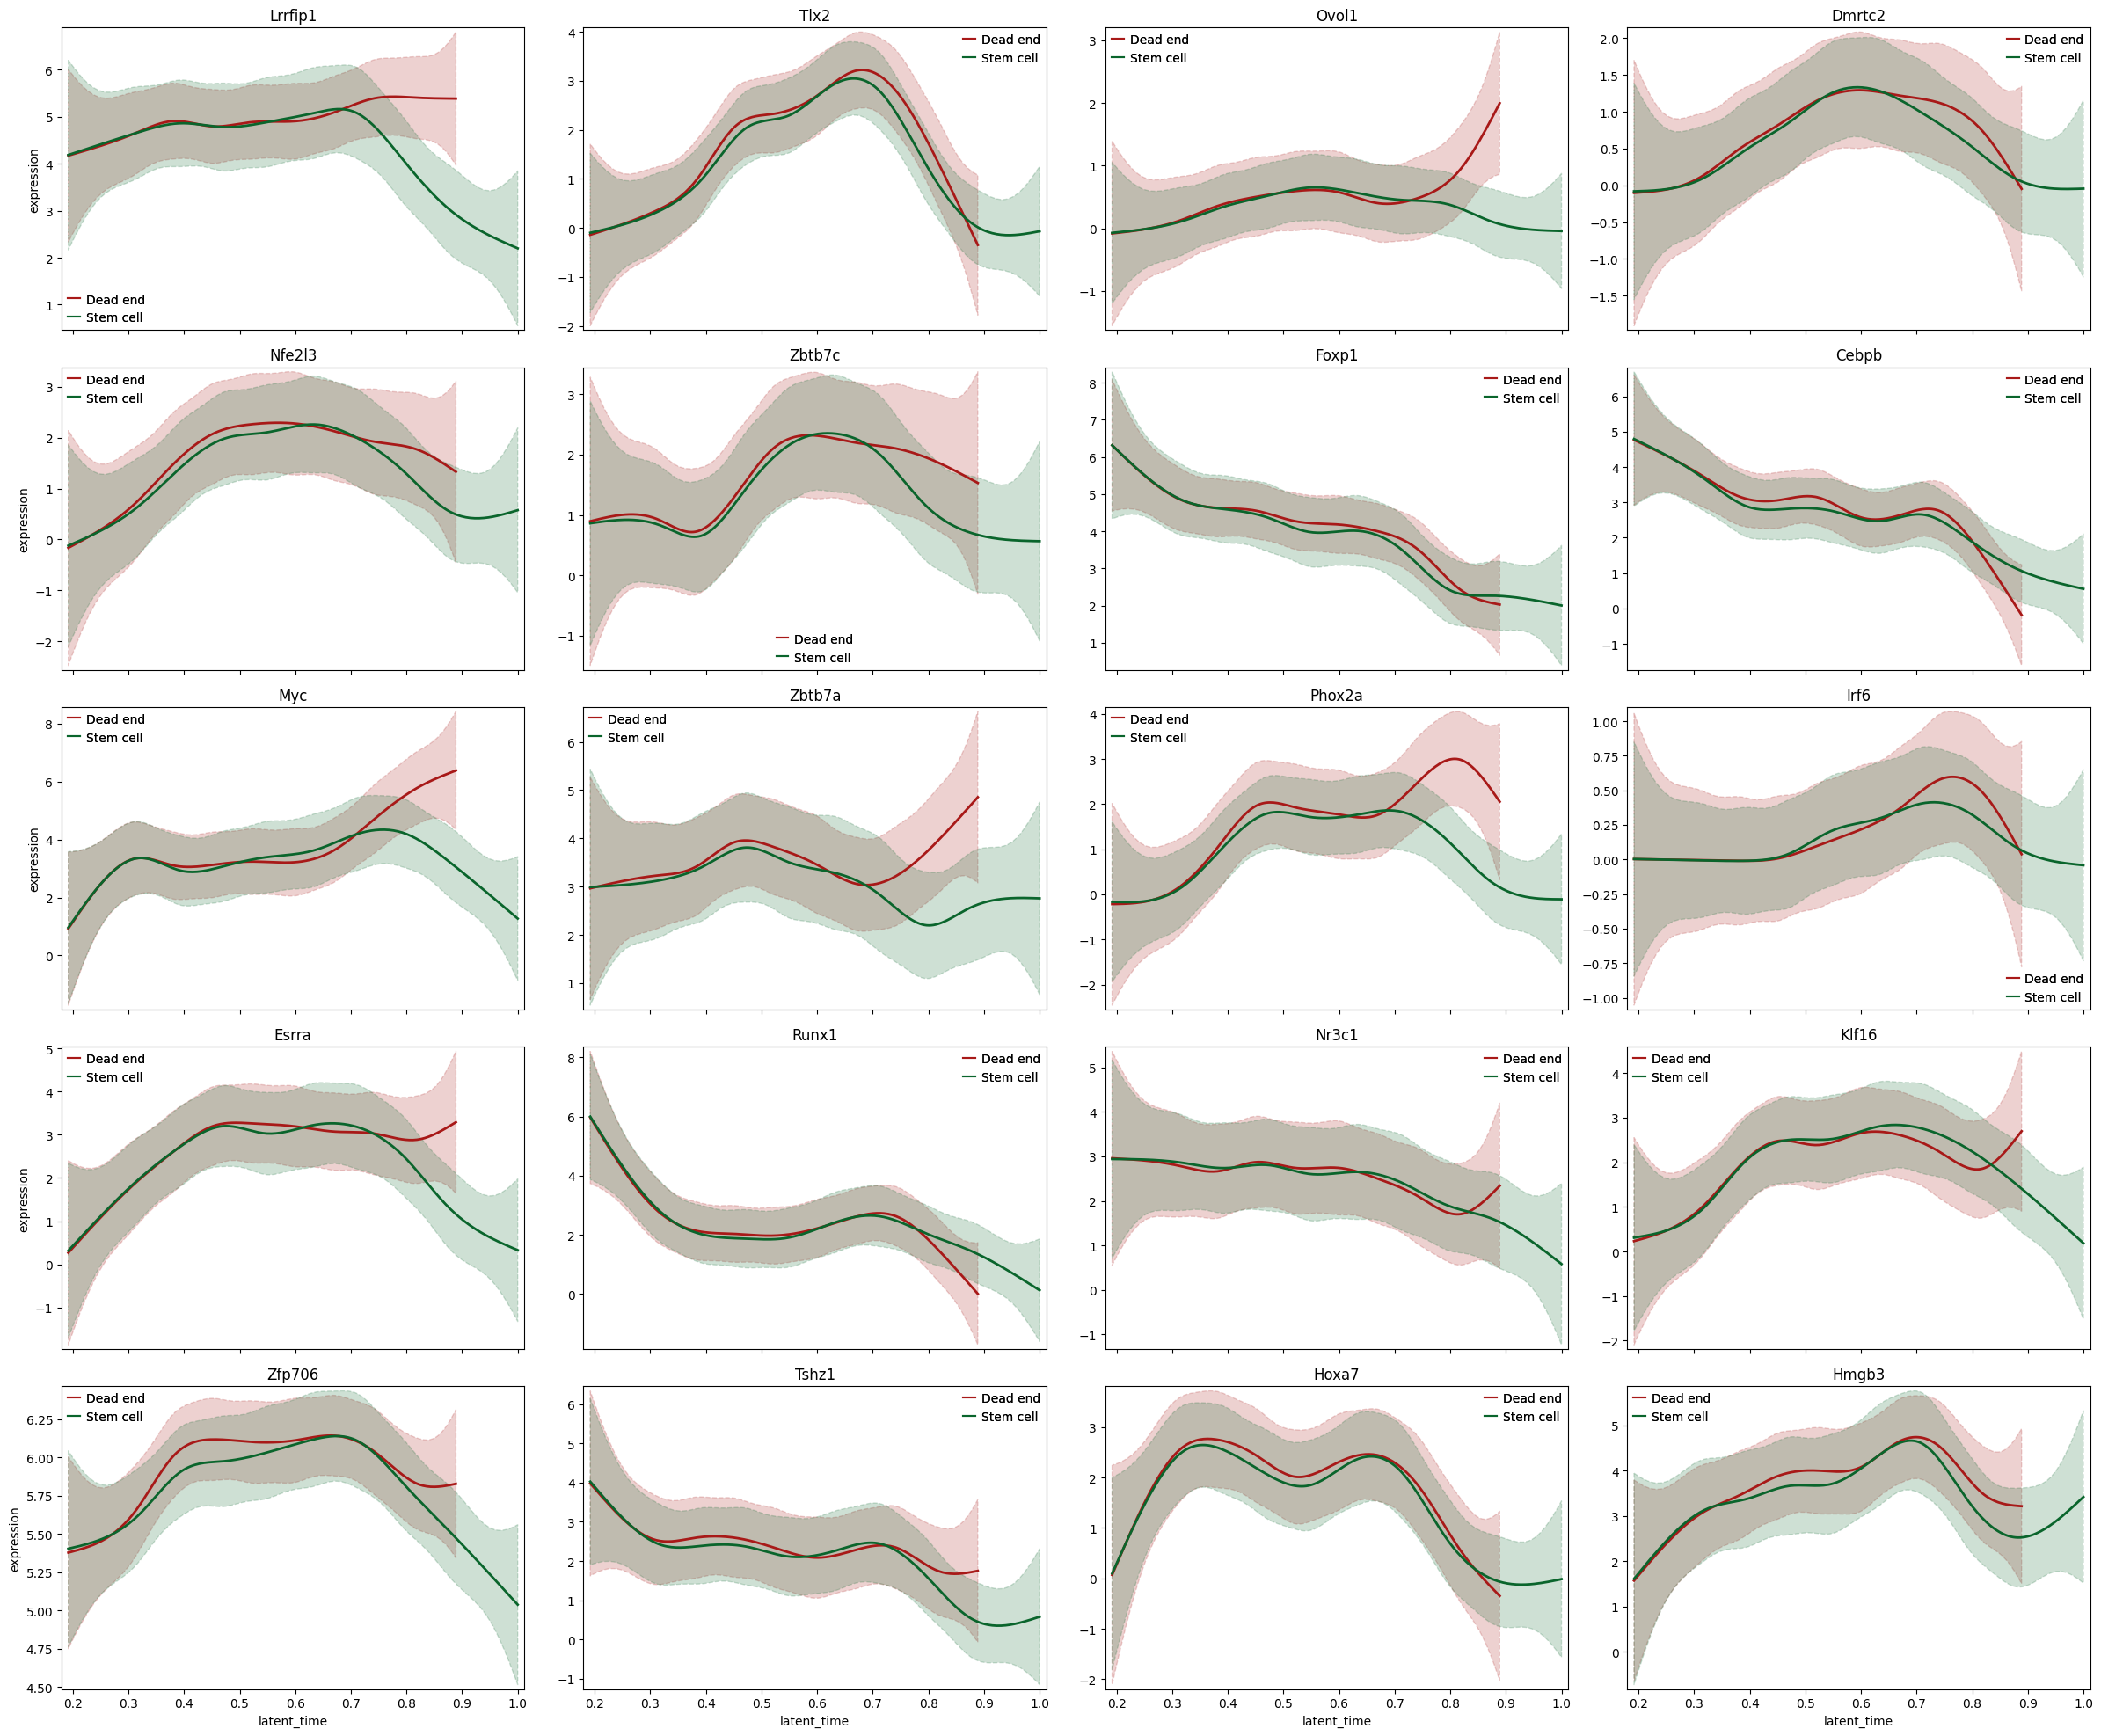

In [37]:
# Expression of dead end drivers

single_cell_analysis.plot_trends_by_trajectory(
    adata, 
    dead_end_drivers, 
    group_key="group",
    groups=["control"],
    layer="raw"
)

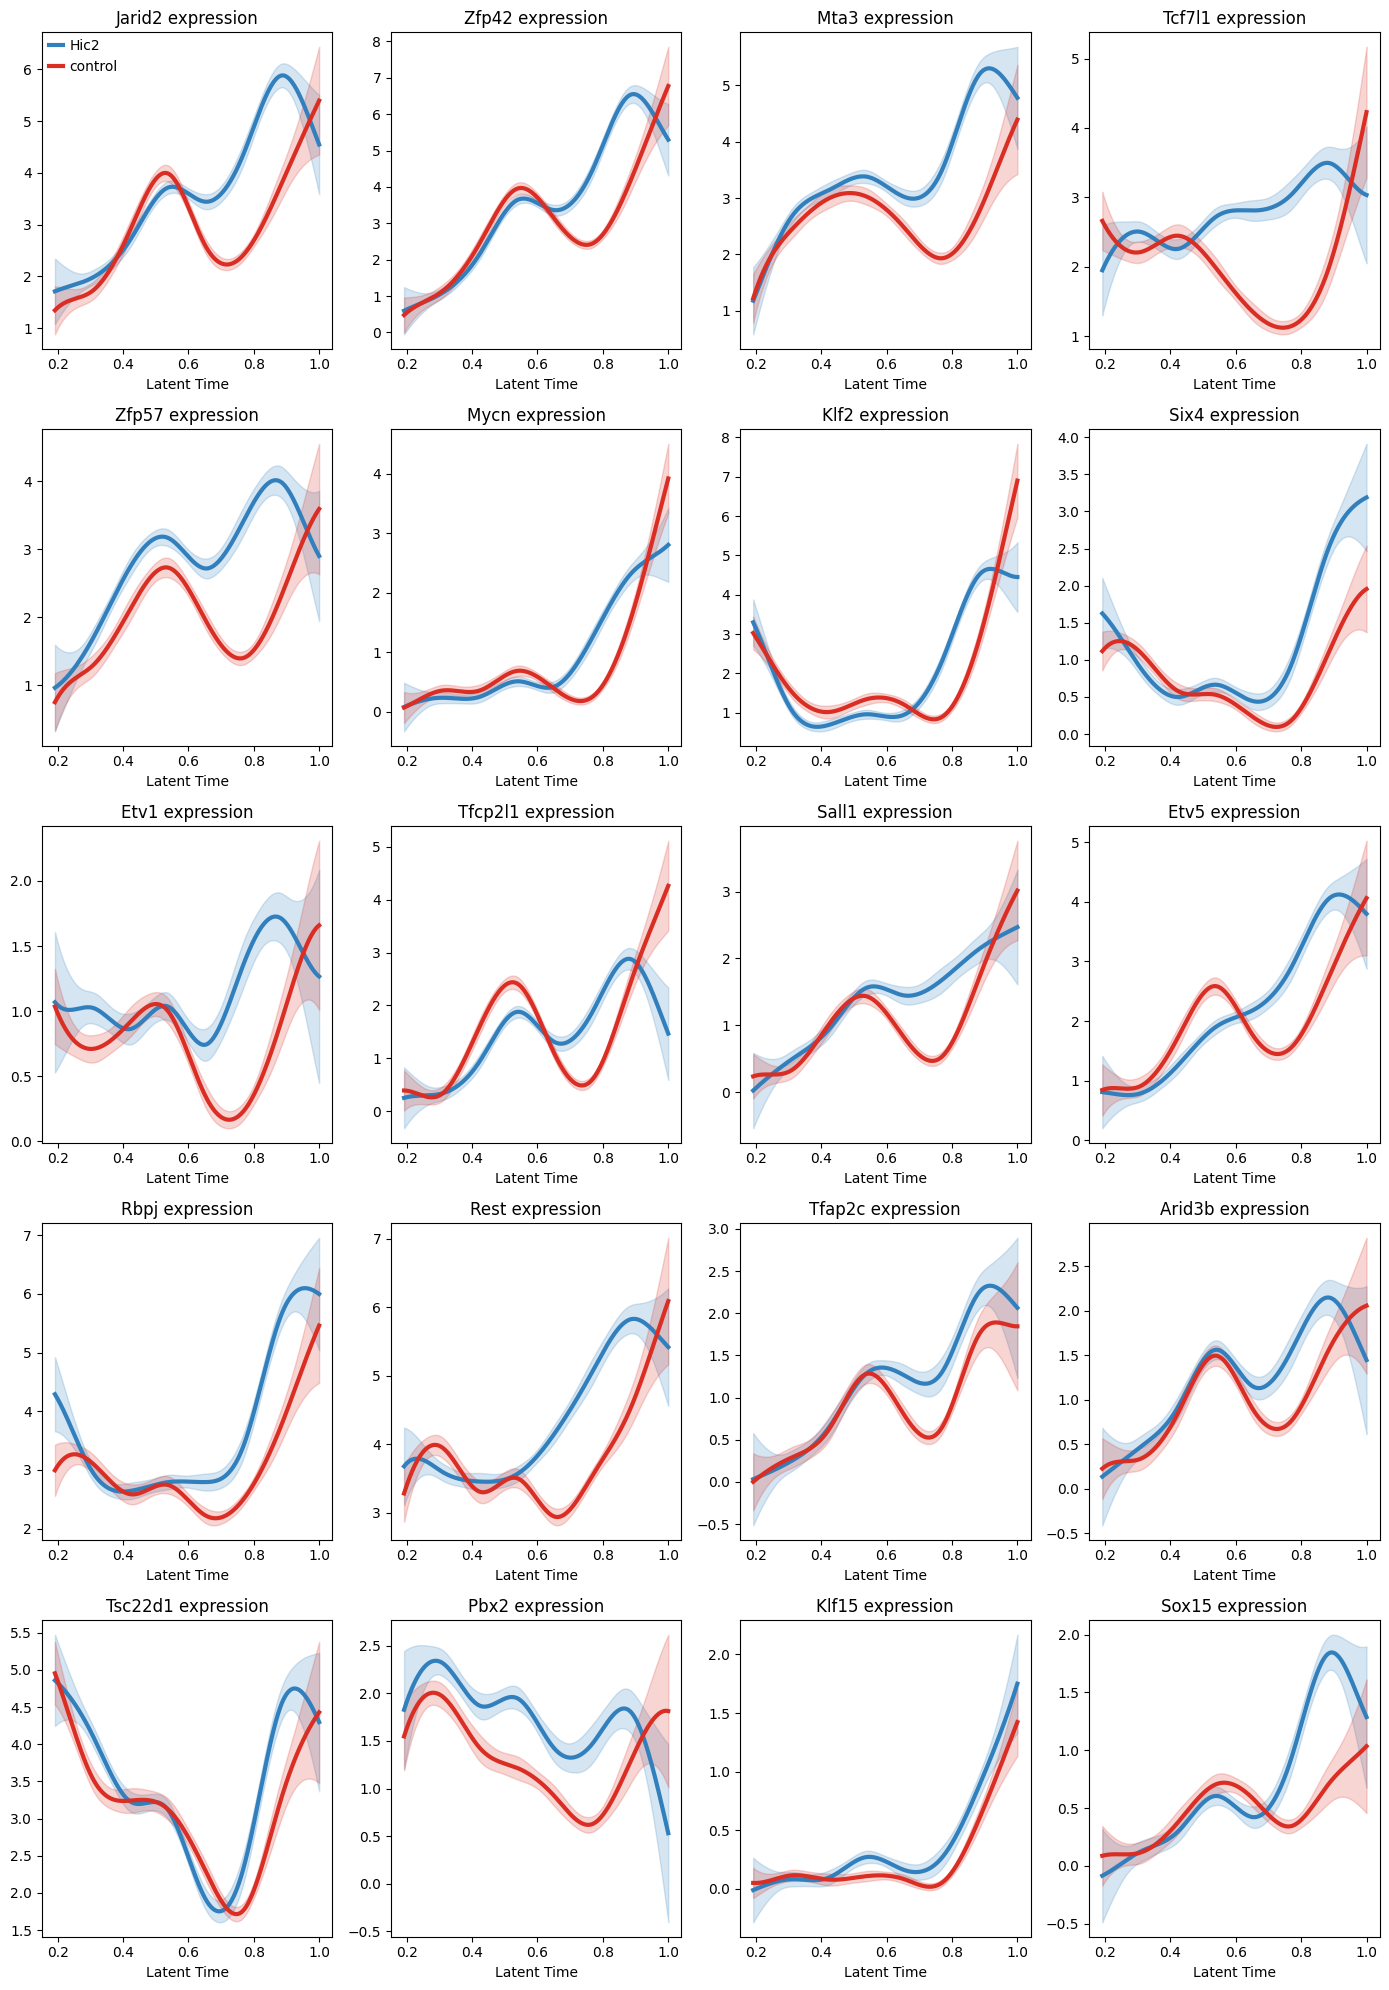

In [34]:
# Expression of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    stem_cell_drivers,
    group_key="group",
    groups=["Hic2", "control"],
    layer="raw"
)

  0%|          | 0/20 [00:00<?, ?gene/s]

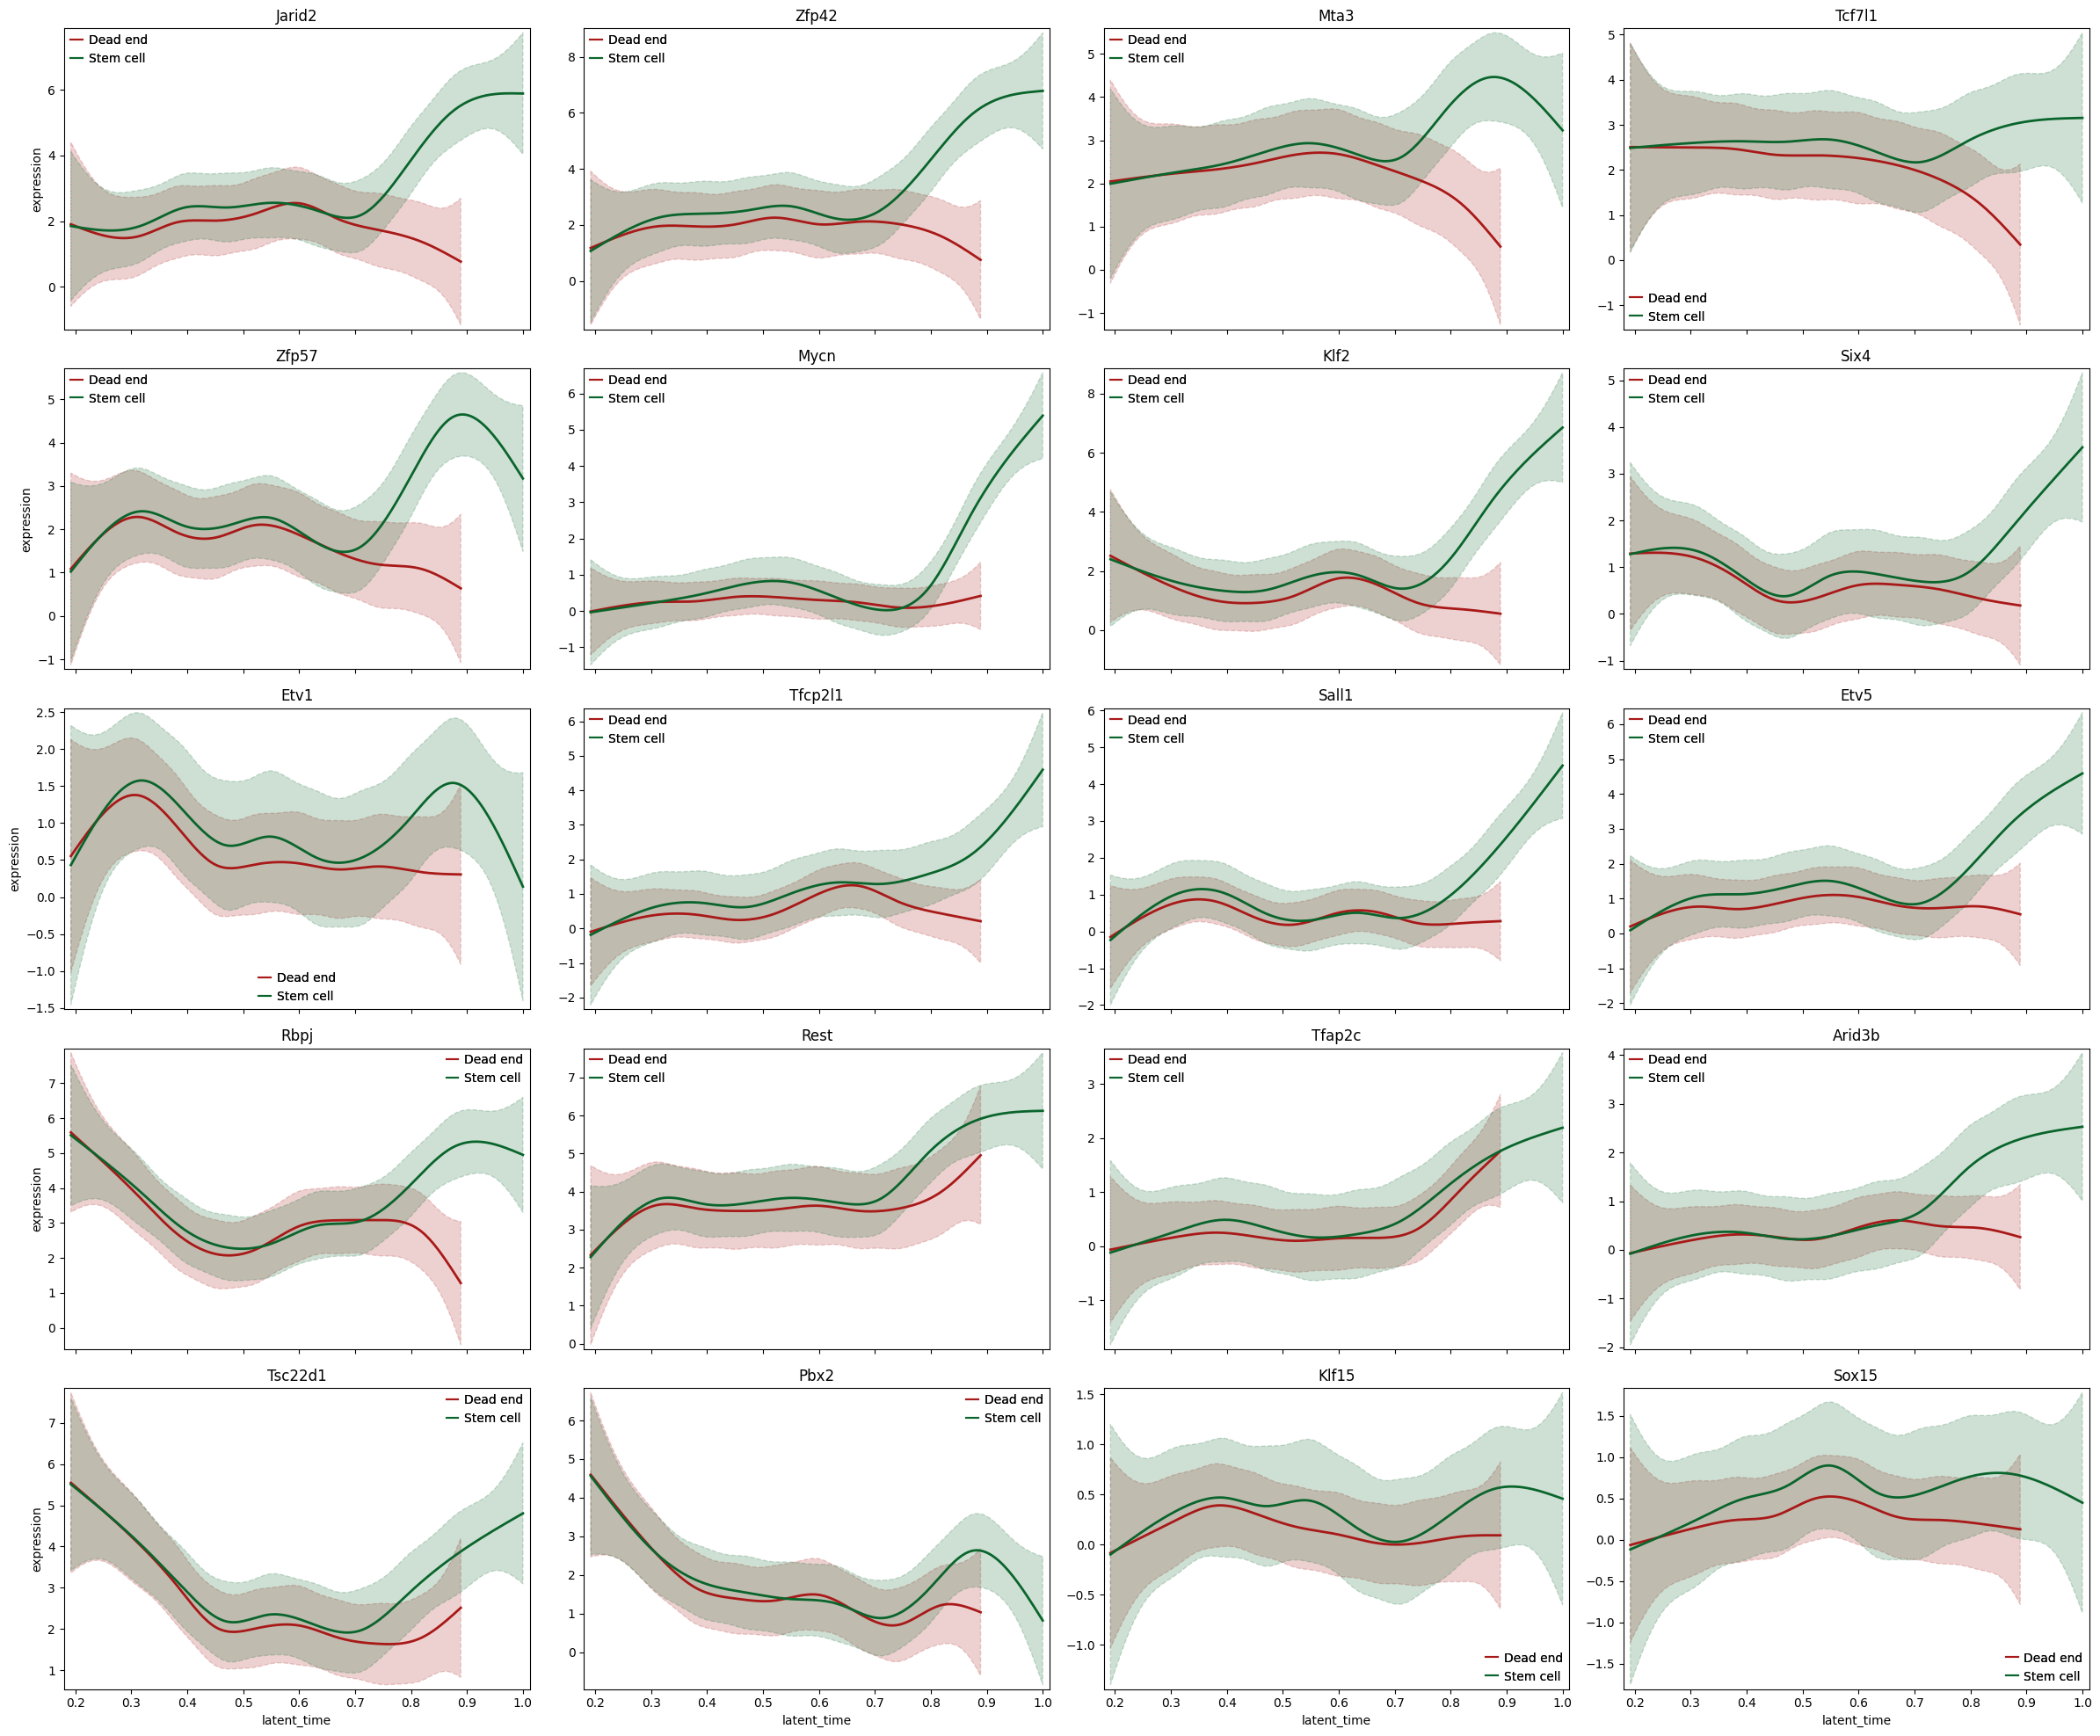

In [38]:
# Expression of stem cell drivers

single_cell_analysis.plot_trends_by_trajectory(
    adata, 
    stem_cell_drivers, 
    group_key="group",
    groups=["control"],
    layer="raw"
)

# Compare activities with Decoupler

In [2]:
# Load collectri
collectri_df = decoupler.op.collectri(organism="mouse")
# Remove unreliable signs
modified_collectri = collectri_df.query("sign_decision != 'default activation'")
# Remove autoregulation
modified_collectri = modified_collectri.query("not (source == target)")

HTTPError: 404 Client Error: Not Found for url: https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz

In [59]:
# Convert 'TARGET_GENE' -> 'Target_gene'
# net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
# net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
decoupler.mt.ulm(adata, net=modified_collectri, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-03-12 14:41:22 | [INFO] ulm - Running ulm
2026-03-12 14:41:22 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-03-12 14:41:22 | [INFO] Network adjacency matrix has 1118 unique features and 459 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-03-12 14:41:22 | [INFO] ulm - fitting 459 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-03-12 14:41:23 | [INFO] ulm - adjusting p-values by FDR
2026-03-12 14:41:23 | [INFO] ulm - done


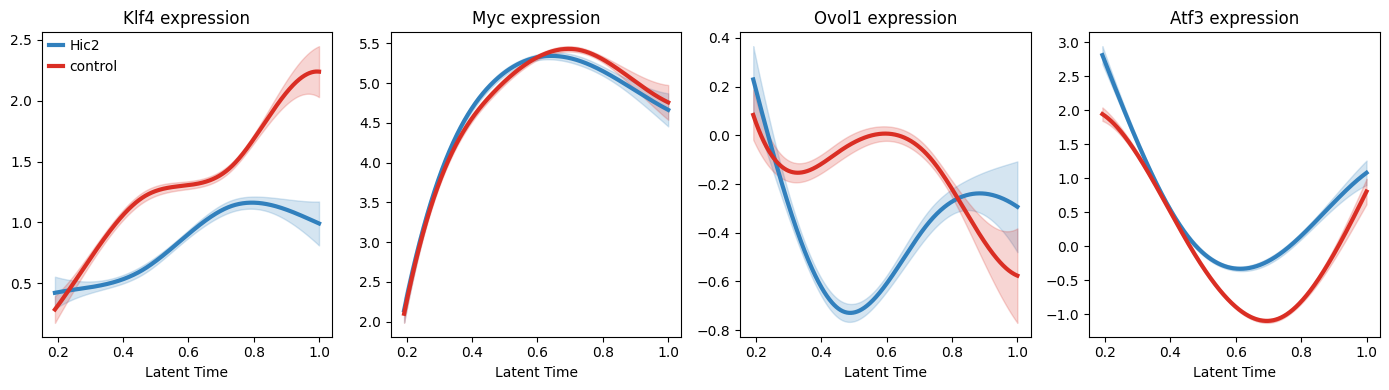

In [62]:
# Activity of interesting genes

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Ovol1", "Atf3"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

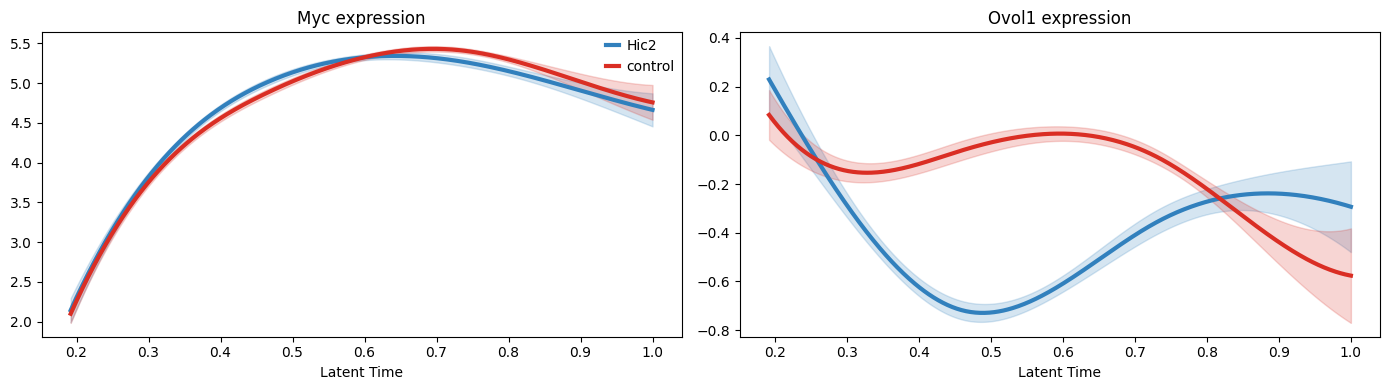

In [63]:
# Activity of dead end TFs

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Ovol1 activity is surprisingly higher in Hic2 cells, despite much lower expression.

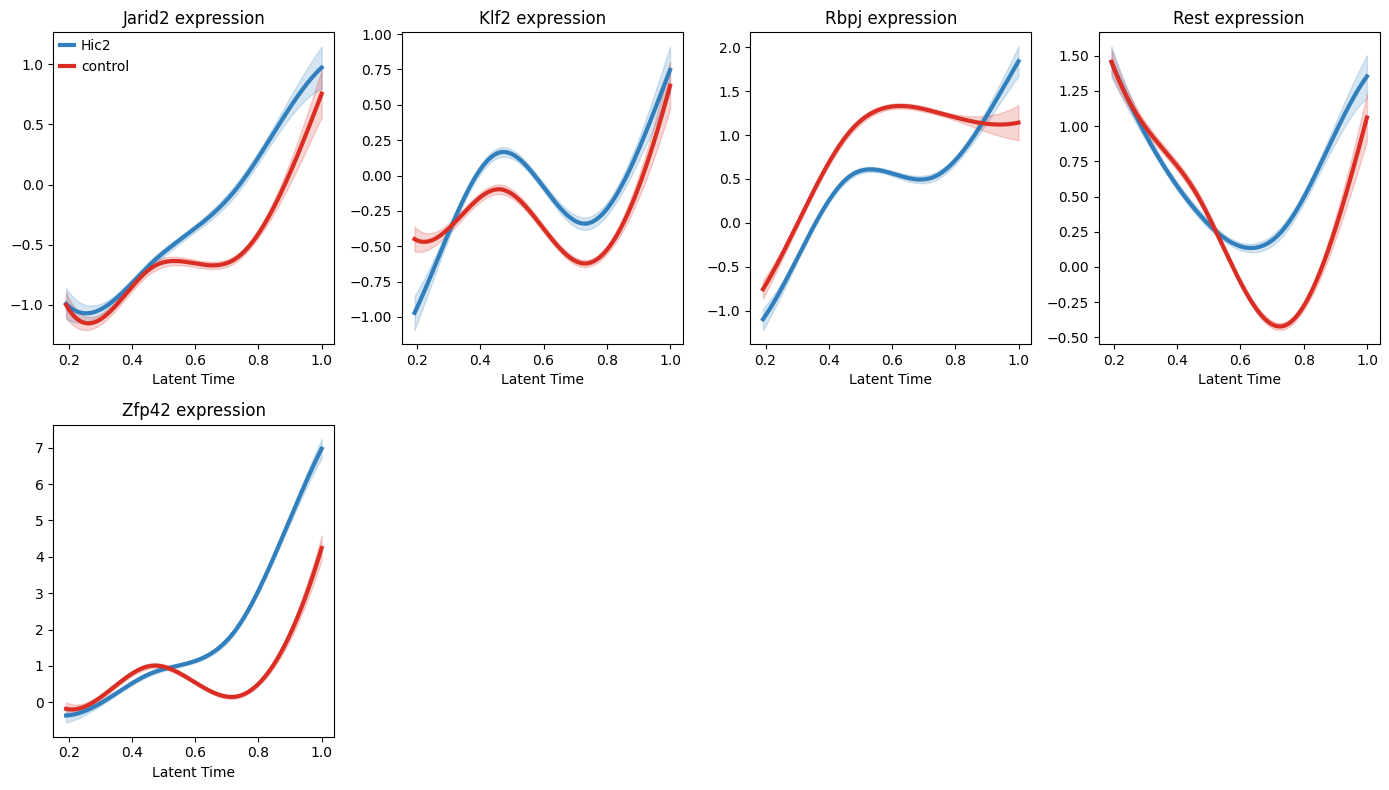

In [64]:
# Activity of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Jarid2 and Zfp42 activities follow almost the exact same trends as their mRNA levels. They are similar until Hic2 and control cells start to take different trajectories. Rest has similar trends as its mRNA expression.

In [65]:
def load_enrichr_as_network(library_name):
    # 1. Download the library using GSEApy
    # Returns a dictionary: {'Term_Name': ['GeneA', 'GeneB', ...]}
    gs_dict = gseapy.get_library(name=library_name, organism='Mouse')
    
    network_list = []
    
    for term, genes in gs_dict.items():
        # The term usually looks like "KLF4 DOWN ..." or "KLF4_MOUSE_..."
        # We need to extract the TF name. 
        # CAUTION: This splitting depends on the specific naming convention of the library
        # For 'TF_Perturbations_Followed_by_Expression', format is often "TF_Perturbation_Direction"
        # We will attempt to grab the first word as the TF name
        if library_name in {"PerturbSeq_ReplogleK562", "PerturbSeq_ReplogleRPE1"}:
            tf_name = term.split()[1].upper()
        else:
            tf_name = term.split()[0].split('_')[0].upper() 
        
        for gene in genes:
            network_list.append({
                'source': tf_name,
                'target': gene,
                'weight': 1.0,      # We assume all targets are equal
                'collection': term  # Keep original term just in case
            })
            
    return pandas.DataFrame(network_list)

In [67]:
# Load another library
perturbation_network = load_enrichr_as_network('TF_Perturbations_Followed_by_Expression') # Has the most genes because it is a collection

2026-03-12 14:44:32 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-12 14:44:32 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.TF_Perturbations_Followed_by_Expression.gmt, use local file


In [ ]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
decoupler.mt.ulm(adata, net=net, verbose=True)

2026-03-12 14:45:02 | [INFO] ulm - Running ulm
2026-03-12 14:45:02 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-03-12 14:45:02 | [INFO] Network adjacency matrix has 1744 unique features and 342 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-03-12 14:45:02 | [INFO] ulm - fitting 342 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-03-12 14:45:03 | [INFO] ulm - adjusting p-values by FDR
2026-03-12 14:45:03 | [INFO] ulm - done


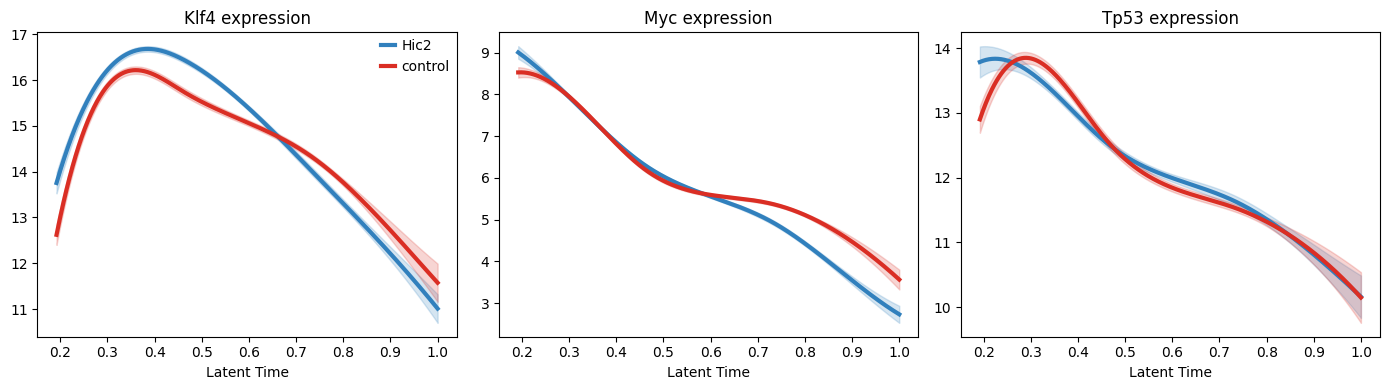

In [70]:
# Activity of interesting genes

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Tp53"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

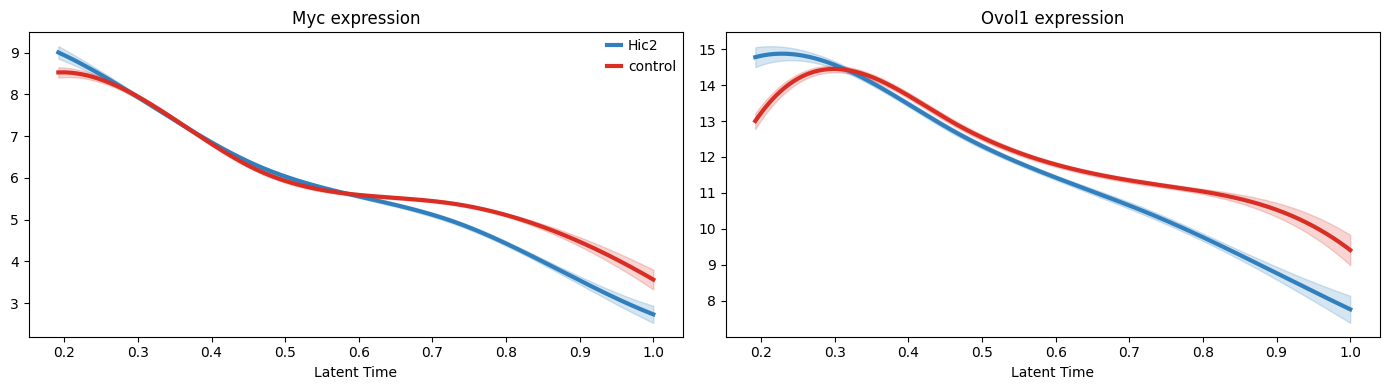

In [71]:
# Activity of dead end TFs

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

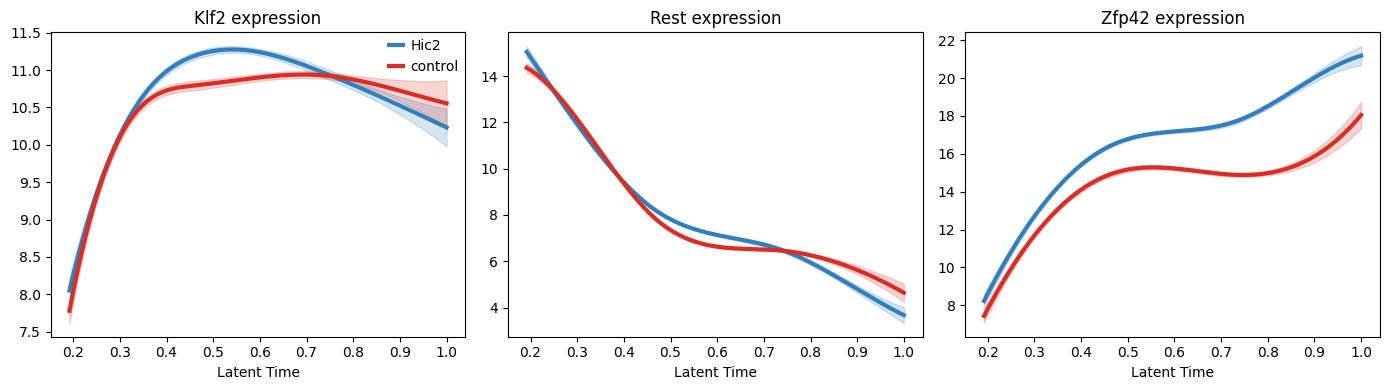

In [72]:
# Activity of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

In [82]:
# Cellrank gene trends for dead end


def plot_tf_trends(adata, tfs, time_key, model=None, group_key="group"):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # Extract the ULM scores (Cell x TF matrix)
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = scanpy.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # Setup the CellRank model if not provided
    if model is None:
        model = cellrank.models.GAMR(tf_adata)
        
    # Plot using the standard function
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    lineages = ["Stem cell", "Dead end"],
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

  0%|          | 0/3 [00:00<?, ?gene/s]

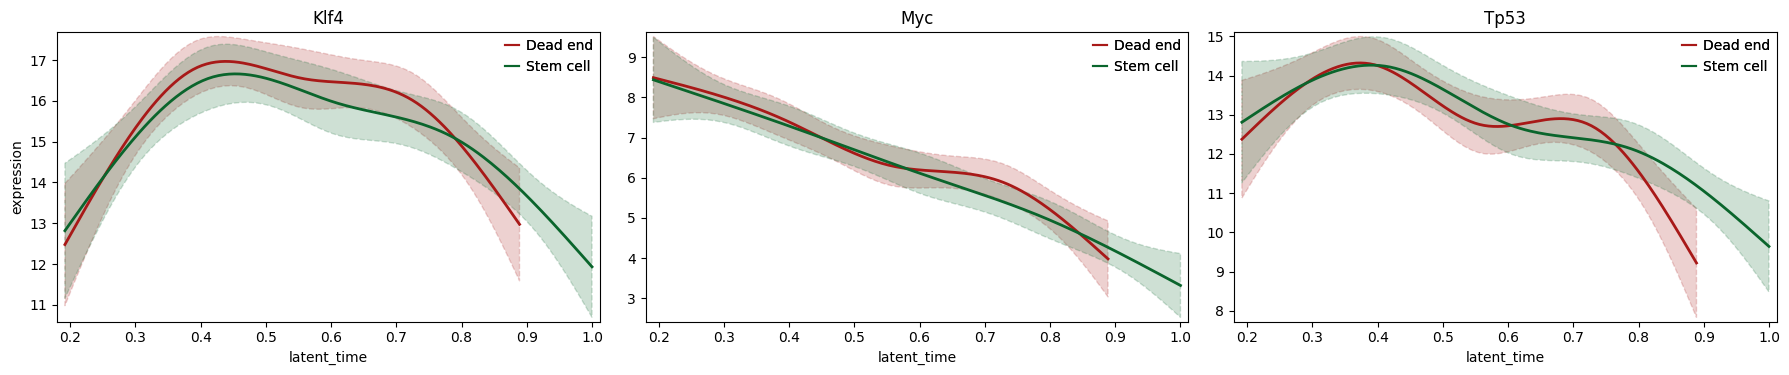

In [83]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(["Klf4", "Myc", "Tp53"], adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/2 [00:00<?, ?gene/s]

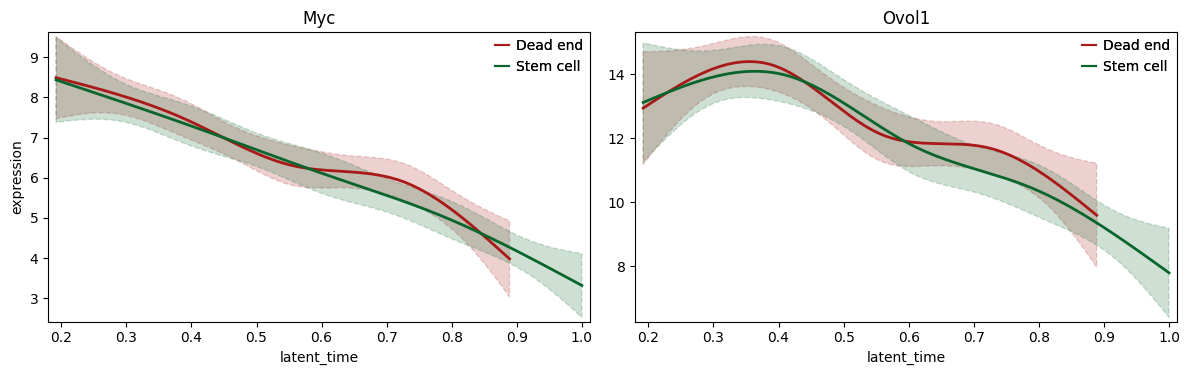

In [84]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/3 [00:00<?, ?gene/s]

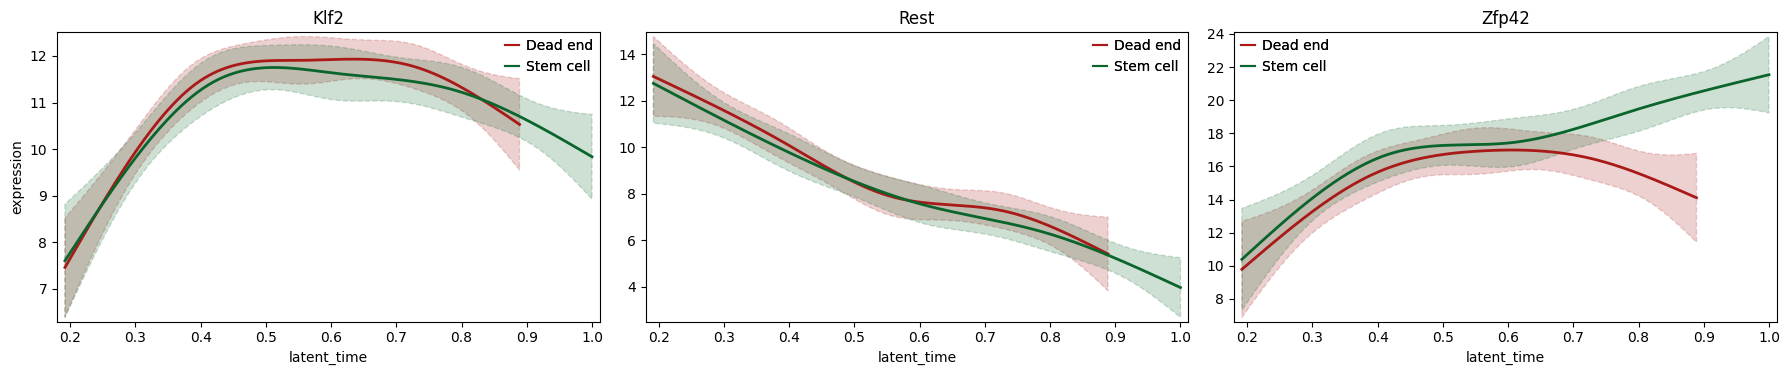

In [85]:
# Cellrank gene trends for stem cells

plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Zfp42 activity is interesting, as it increases in the mESC cells. The other genes do not look like clear reprogramming drivers.

# Conclusions

The most important target of Hic2 is Ovol1. It downregulates c-Myc (https://www.nature.com/articles/modpathol2016169) and inhibits the epithelial to mesenchymal transition by degrading the TGF-β receptor type 1 while promoting mesenchymal-to-epithelial transition (https://www.nature.com/articles/s41392-022-00944-w).